In [1]:
import numpy as np
import pandas as pd

import librosa
import librosa.display

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, DepthwiseConv2D, MaxPooling2D, GlobalAveragePooling2D, Conv2D
from tensorflow.keras.regularizers import l2

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

import seaborn as sns

import os
import shutil
import json

In [2]:
# Set MFCC parameters
N_MFCC = 13 
N_MELS = 26
N_FRAMES = 200
SAMPLING_RATE = 16000 # 16 kHz
FRAME_SIZE = 512 # 32 ms
HOP_LENGTH = 256 # 16 ms
MIN_FREQ = 50
MAX_FREQ = SAMPLING_RATE / 2


**1. Preparing the data**

In [3]:
# Read train_csv
df1 = pd.read_csv('../data/cv-valid-train.csv')

# Filter rows where the 'gender' column is not null
df1 = df1[df1['gender'].notna()]

# Select only the 'filename' and 'gender' columns
df1 = df1[['filename', 'gender']]

# Print the number of samples in the dataset
print('Number of samples:', len(df1))

Number of samples: 200


In [4]:
# Do the same for dev_csv
df2 = pd.read_csv('../data/cv-valid-dev.csv')
df2 = df2[df2['gender'].notna()]
df2 = df2[['filename', 'gender']]
print('Number of samples:', len(df2))

# Do the same for test_csv
df3 = pd.read_csv('../data/cv-valid-test.csv')
df3 = df3[df3['gender'].notna()]
df3 = df3[['filename', 'gender']]
print('Number of samples:', len(df3))

Number of samples: 100
Number of samples: 100


In [5]:
# Convert dataframes to lists
train_files = set(df1['filename'].tolist())
dev_files = set(df2['filename'].tolist())
test_files = set(df3['filename'].tolist())

# Define source folders for the dataset
data = {
    "../data/cv-valid-train": train_files,
    "../data/cv-valid-dev": dev_files,
    "../data/cv-valid-test": test_files,
}

# Define destination folder for combined dataset
dst_folder = '../data/combined_dataset_gender'

# Create the destination folder if it does not exist
if not os.path.exists(dst_folder):
    os.makedirs(dst_folder)

    # Copy only files present in dataframes and append a prefix to the filename
    for dataset, file_list in data.items():
        for file in os.listdir(dataset):
            basename = os.path.basename(dataset)
            filename = basename + '/' + file
            if filename in file_list:
                src_path = os.path.join(dataset, file)
                dst_path = os.path.join(dst_folder, basename + '_' + file)
                shutil.copyfile(src_path, dst_path)

In [6]:
# Combine to a single dataframe
df_combined = pd.concat([df1, df2, df3])

# Drop the 'other' gender
df_combined = df_combined[df_combined['gender'] != 'other']

# Print the number of samples in the combined dataset by gender
gender_counts = df_combined['gender'].value_counts()
print(gender_counts)

male      306
female     92
Name: gender, dtype: int64


In [7]:
def normalize_audio(audio):
    # Perform normalization to range [-1, 1]
    max = np.max(np.abs(audio))
    if max > 0:
        audio /= max
    return audio

# Function to get array from audio file
def get_audio_snippets_from_audio_file(audio_file):
    y, sr = librosa.load(audio_file, sr=SAMPLING_RATE)
    
    target_length = FRAME_SIZE + (N_FRAMES - 1) * HOP_LENGTH

    audio_array = []

    if len(y) < target_length:
        # Pad the audio array if it is shorter than the target length
        padding_size = target_length - len(y)
        pad_left = padding_size // 2
        pad_right = padding_size - pad_left
        y = np.pad(y, (pad_left, pad_right))  # Pad both sides
        
        audio_array.append(y)
    else:
        num_audio_snippets = len(y) // target_length

        for i in range(num_audio_snippets):
            audio_snippet = y[i * target_length:(i + 1) * target_length]
            audio_array.append(audio_snippet)

        # If the remainder of the audio doesn't fill a full snippet
        remainder = len(y) % target_length
        if remainder > 0:
            # Pad the last snippet to reach the target length
            audio_snippet = y[-remainder:]  # Get the last part
            pad_left = (target_length - remainder) // 2
            pad_right = (target_length - remainder) - pad_left
            audio_snippet = np.pad(audio_snippet, (pad_left, pad_right))
            audio_array.append(audio_snippet)

    # Convert to numpy array
    audio_array = np.array(audio_array)

    return audio_array

# Function to get MFCC from array
def extract_mfcc(data):

    # Compute the MFCC
    mfcc = librosa.feature.mfcc(
        y=data,  # audio time series
        sr=SAMPLING_RATE,   # sampling rate of y
        n_mfcc=N_MFCC,  # number of MFCCs to return 
        n_mels=N_MELS,  # number of Mel bands to generate
        n_fft=FRAME_SIZE,  # length of the FFT window
        hop_length=HOP_LENGTH,  # number of samples between successive frames
        fmin=MIN_FREQ,  # lowest frequency (in Hz)
        fmax=MAX_FREQ,  # highest frequency (in Hz)
        window='hann',
        center=False,  # disable centering of the frames
        dct_type=2,  # discrete cosine transform (DCT) type
        norm='ortho',  # setting norm='ortho' uses an ortho-normal DCT basis
        power=2,  # exponent applied to the spectrum 
        )

    return mfcc

# Function to extract MFCCs for a given dataframe
def extract_mfccs_for_dataset(df, audio_folder):
    mfccs = []
    labels = []

    for index, row in df.iterrows():
        filename_in_df = row['filename']
        filename_in_dataset = filename_in_df.replace("/", "_")
        gender = row['gender']

        # Path to audio file (update this path according to your setup)
        audio_path = os.path.join(audio_folder, filename_in_dataset)

        snippets = get_audio_snippets_from_audio_file(audio_path)

        for snippet in snippets:
            normalized_snippet = normalize_audio(snippet)
            mfcc = extract_mfcc(normalized_snippet)
            mfccs.append(mfcc)
            labels.append(gender)

    # Convert to numpy arrays
    mfccs = np.array(mfccs)
    labels = np.array(labels)

    return mfccs, labels

In [8]:
# Extract MFCCs for the combined dataset
data_folder = '../data/combined_dataset_gender'
mfccs, labels = extract_mfccs_for_dataset(df_combined, data_folder)

# Print the shape of the MFCCs and labels
print('MFCCs shape:', mfccs.shape)
print('Labels shape:', labels.shape)

# Save the MFCCs and labels to disk
np.save('mfccs.npy', mfccs)
np.save('labels.npy', labels)

MFCCs shape: (677, 13, 200)
Labels shape: (677,)


In [9]:
# Load the MFCCs and labels from disk
mfccs = np.load('mfccs.npy')
labels = np.load('labels.npy')

**2. Processing the data**

In [10]:
# Create a dataframe from the mfccs and labels
df_mfcc = pd.DataFrame()
df_mfcc['mfccs'] = list(mfccs)
df_mfcc['labels'] = list(labels)

In [11]:
# Count number of female and male instances in dataframe
print(df_mfcc['labels'].value_counts())

male      513
female    164
Name: labels, dtype: int64


In [12]:
# Find the count of female instances
female_count = df_mfcc[df_mfcc['labels'] == 'female'].shape[0]

# Split the dataset into male and female
df_male = df_mfcc[df_mfcc['labels'] == 'male']
df_female = df_mfcc[df_mfcc['labels'] == 'female']

# Downsample the male instances
df_male_downsampled = df_male.sample(n=female_count, random_state=43)

# Combine the downsampled male data with the female data
df_balanced = pd.concat([df_female, df_male_downsampled])

# Print the number of samples in the combined dataset by gender
gender_counts = df_balanced['labels'].value_counts()
print(gender_counts)

print('Number of samples:', len(df_balanced))

female    164
male      164
Name: labels, dtype: int64
Number of samples: 328


In [13]:
# Shuffle the dataframe
df_balanced = df_balanced.sample(frac=1, random_state=43).reset_index(drop=True)

# Define new split ratio
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15

# Compute split sizes
train_size = int(train_ratio * len(df_balanced))
val_size = int(val_ratio * len(df_balanced))

# Split the dataframe with stratification
df_train, df_temp = train_test_split(df_balanced, test_size=(1 - train_ratio), stratify=df_balanced['labels'], random_state=43)
df_val, df_test = train_test_split(df_temp, test_size=test_ratio / (val_ratio + test_ratio), stratify=df_temp['labels'], random_state=43)

# Check the shape of the dataframes
print(f"Train dataframe shape: {df_train.shape}")
print(f"Validation dataframe shape: {df_val.shape}")
print(f"Test dataframe shape: {df_test.shape}")

Train dataframe shape: (229, 2)
Validation dataframe shape: (49, 2)
Test dataframe shape: (50, 2)


In [14]:
# Split back the MFCCs and labels
train_mfccs, train_labels = np.array(df_train['mfccs'].tolist()), np.array(df_train['labels'].tolist())
val_mfccs, val_labels = np.array(df_val['mfccs'].tolist()), np.array(df_val['labels'].tolist())
test_mfccs, test_labels = np.array(df_test['mfccs'].tolist()), np.array(df_test['labels'].tolist())

In [15]:
# Save the MFCCs and labels to disk
np.save('train_mfccs.npy', train_mfccs)
np.save('train_labels.npy', train_labels)
np.save('val_mfccs.npy', val_mfccs)
np.save('val_labels.npy', val_labels)
np.save('test_mfccs.npy', test_mfccs)
np.save('test_labels.npy', test_labels)

In [16]:
# Load the MFCCs and labels from disk
train_mfccs = np.load('train_mfccs.npy')
train_labels = np.load('train_labels.npy')
val_mfccs = np.load('val_mfccs.npy')
val_labels = np.load('val_labels.npy')
test_mfccs = np.load('test_mfccs.npy')
test_labels = np.load('test_labels.npy')

In [17]:
# Reshape the MFCCs for CNN input: (N_MFCC, N_FRAMES, 1) for each sample
# Adding the channel dimension (1) at the end of the shape for the Conv2D layer
train_mfccs = train_mfccs.reshape((-1, N_MFCC, N_FRAMES, 1))
val_mfccs = val_mfccs.reshape((-1, N_MFCC, N_FRAMES, 1))
test_mfccs = test_mfccs.reshape((-1, N_MFCC, N_FRAMES, 1))

# Check the shapes of the resulting MFCC arrays
print(f"Train MFCCs shape: {train_mfccs.shape}")
print(f"Validation MFCCs shape: {val_mfccs.shape}")
print(f"Test MFCCs shape: {test_mfccs.shape}")

Train MFCCs shape: (229, 13, 200, 1)
Validation MFCCs shape: (49, 13, 200, 1)
Test MFCCs shape: (50, 13, 200, 1)


In [18]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the labels
train_labels = label_encoder.fit_transform(train_labels)
val_labels = label_encoder.transform(val_labels)
test_labels = label_encoder.transform(test_labels)

print(dict(enumerate(label_encoder.classes_))) 

print(label_encoder.classes_)

{0: 'female', 1: 'male'}
['female' 'male']


In [19]:
# Create the Mel filter bank
mel_filter_bank = librosa.filters.mel(sr=SAMPLING_RATE, n_mels=N_MELS, n_fft=FRAME_SIZE, fmin=MIN_FREQ, fmax=MAX_FREQ)

# Format as a C array
c_array = "const float mel_filter_bank[NUM_MEL_FILTERS][N_FFT / 2 + 1] = {\n"
for row in mel_filter_bank:
    c_array += "    {" + ", ".join(map(str, row)) + "},\n"
c_array = c_array.rstrip(",\n") + "\n};"

# Save as a C header file
with open("mel_filter_bank.h", "w") as f:
    f.write("#ifndef MEL_FILTER_BANK_H\n")
    f.write("#define MEL_FILTER_BANK_H\n\n")
    f.write("#define NUM_MEL_FILTERS {}\n".format(mel_filter_bank.shape[0]))
    f.write("#define N_FFT {}\n\n".format((mel_filter_bank.shape[1] - 1) * 2))
    f.write(c_array + "\n\n")
    f.write("#endif // MEL_FILTER_BANK_H\n")

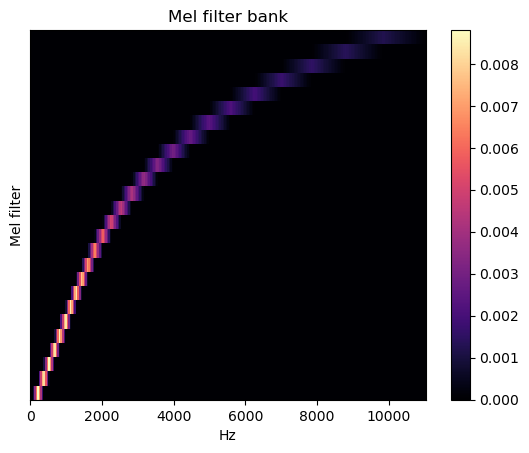

In [20]:
fig, ax = plt.subplots()
img = librosa.display.specshow(mel_filter_bank, x_axis='linear', ax=ax)
ax.set(ylabel='Mel filter', title='Mel filter bank')
fig.colorbar(img, ax=ax)

**3. Training the model**

In [21]:
# Model definition
model = Sequential([
    Input(shape=(N_MFCC, N_FRAMES, 1)),

    Conv2D(16, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)), 

    Conv2D(32, (3,3), activation='relu', padding='same'),
    Dropout(0.2),
    MaxPooling2D((2,2)),  

    DepthwiseConv2D((3,3), activation='relu', padding='same'), 
    MaxPooling2D((2,2)), 

    GlobalAveragePooling2D(),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])


# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Implement early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

# Implement learning rate scheduler
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, verbose=1
)

In [22]:
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 13, 200, 16)       160       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 6, 100, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 6, 100, 32)        4640      
                                                                 
 dropout (Dropout)           (None, 6, 100, 32)        0         
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 3, 50, 32)        0         
 2D)                                                             
                                                                 
 depthwise_conv2d (Depthwise  (None, 3, 50, 32)        3

In [23]:
# Run the model
history = model.fit(
    train_mfccs, train_labels,
    validation_data=(val_mfccs, val_labels),
    epochs=1000,
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/1000
8/8 [==============================] - 2s 104ms/step - loss: 1.3480 - accuracy: 0.4847 - val_loss: 0.8062 - val_accuracy: 0.5102 - lr: 0.0010
Epoch 2/1000
8/8 [==============================] - 1s 88ms/step - loss: 0.9278 - accuracy: 0.5197 - val_loss: 0.7247 - val_accuracy: 0.4898 - lr: 0.0010
Epoch 3/1000
8/8 [==============================] - 1s 79ms/step - loss: 0.8223 - accuracy: 0.5371 - val_loss: 0.7229 - val_accuracy: 0.5102 - lr: 0.0010
Epoch 4/1000
8/8 [==============================] - 1s 69ms/step - loss: 0.7803 - accuracy: 0.4498 - val_loss: 0.7207 - val_accuracy: 0.5306 - lr: 0.0010
Epoch 5/1000
8/8 [==============================] - 1s 92ms/step - loss: 0.7482 - accuracy: 0.5371 - val_loss: 0.7261 - val_accuracy: 0.4898 - lr: 0.0010
Epoch 6/1000
8/8 [==============================] - 1s 108ms/step - loss: 0.7304 - accuracy: 0.5197 - val_loss: 0.7146 - val_accuracy: 0.5918 - lr: 0.0010
Epoch 7/1000
8/8 [==============================] - 1s 105ms/step - loss: 

Epoch 54/1000
8/8 [==============================] - 0s 61ms/step - loss: 0.5303 - accuracy: 0.7162 - val_loss: 0.5671 - val_accuracy: 0.7347 - lr: 0.0010
Epoch 55/1000
8/8 [==============================] - 1s 68ms/step - loss: 0.5183 - accuracy: 0.7162 - val_loss: 0.5338 - val_accuracy: 0.7755 - lr: 0.0010
Epoch 56/1000
8/8 [==============================] - 1s 60ms/step - loss: 0.5380 - accuracy: 0.7249 - val_loss: 0.5529 - val_accuracy: 0.7143 - lr: 0.0010
Epoch 57/1000
8/8 [==============================] - 0s 56ms/step - loss: 0.4930 - accuracy: 0.7598 - val_loss: 0.5387 - val_accuracy: 0.7755 - lr: 0.0010
Epoch 58/1000
8/8 [==============================] - ETA: 0s - loss: 0.5062 - accuracy: 0.7380
Epoch 58: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
8/8 [==============================] - 1s 65ms/step - loss: 0.5062 - accuracy: 0.7380 - val_loss: 0.5378 - val_accuracy: 0.7143 - lr: 0.0010
Epoch 59/1000
8/8 [==============================] - 0s 55ms/step -

Epoch 103/1000
8/8 [==============================] - 0s 64ms/step - loss: 0.4343 - accuracy: 0.7948 - val_loss: 0.4618 - val_accuracy: 0.8163 - lr: 1.2500e-04
Epoch 104/1000
8/8 [==============================] - 1s 70ms/step - loss: 0.4740 - accuracy: 0.7817 - val_loss: 0.4589 - val_accuracy: 0.8571 - lr: 1.2500e-04
Epoch 105/1000
8/8 [==============================] - 1s 65ms/step - loss: 0.4339 - accuracy: 0.8122 - val_loss: 0.4577 - val_accuracy: 0.8367 - lr: 1.2500e-04
Epoch 106/1000
8/8 [==============================] - 1s 61ms/step - loss: 0.4633 - accuracy: 0.7729 - val_loss: 0.4603 - val_accuracy: 0.8571 - lr: 1.2500e-04
Epoch 107/1000
8/8 [==============================] - 1s 65ms/step - loss: 0.4514 - accuracy: 0.7991 - val_loss: 0.4591 - val_accuracy: 0.8367 - lr: 1.2500e-04
Epoch 108/1000
8/8 [==============================] - 1s 72ms/step - loss: 0.4296 - accuracy: 0.7991 - val_loss: 0.4604 - val_accuracy: 0.8571 - lr: 1.2500e-04
Epoch 109/1000
8/8 [====================

**4. Evaluating the Model**

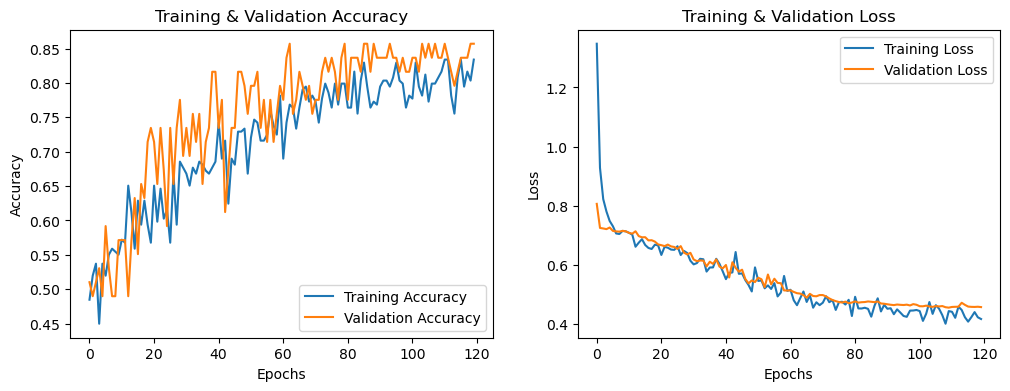

In [24]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')

plt.show()

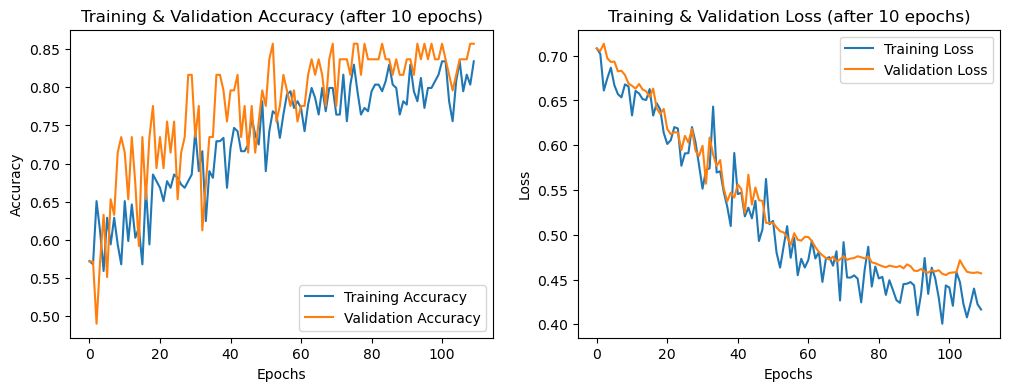

In [25]:
# Plot training hisotry, ignoring the first 10 epochs
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'][10:], label='Training Accuracy')
plt.plot(history.history['val_accuracy'][10:], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy (after 10 epochs)')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'][10:], label='Training Loss')
plt.plot(history.history['val_loss'][10:], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss (after 10 epochs)')

plt.show()

2/2 [==============================] - 0s 0s/step


C:\Users\hloh\Anaconda3\envs\tf\lib\site-packages\sklearn\preprocessing\_label.py:153: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


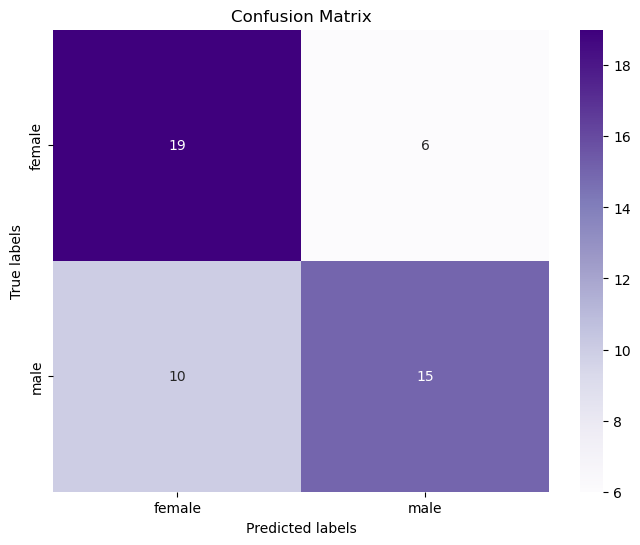

In [26]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_mfccs, test_labels)

predictions = model.predict(test_mfccs)

# Convert the labels back to their original values
test_labels_categ = label_encoder.inverse_transform(test_labels)

# Convert the predictions to binary values
predicted_labels = (predictions > 0.5).astype(int)  # Converts probabilities to 0 or 1
predicted_labels = label_encoder.inverse_transform(predicted_labels)

# Create confusion matrix
conf_matrix = confusion_matrix(test_labels_categ, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Purples')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

**4. Conversion to TFLite model**

In [27]:
# Initialize the TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Set to default optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Define a generator function that yields input data
def representative_data_gen():
    for mfcc in test_mfccs[:500]:  # Use first 500 samples
        mfcc = np.expand_dims(mfcc, axis=0)  # Ensure batch dimension
        yield [mfcc.astype(np.float32)]

# Set the representative dataset for quantization
converter.representative_dataset = representative_data_gen

# Convert the model
tflite_model = converter.convert()

# Save the TFLite model
with open("audio_gender_classification_model.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\hloh\AppData\Local\Temp\tmp956zg14i\assets


INFO:tensorflow:Assets written to: C:\Users\hloh\AppData\Local\Temp\tmp956zg14i\assets
C:\Users\hloh\Anaconda3\envs\tf\lib\site-packages\tensorflow\lite\python\convert.py:766: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


In [28]:
# Get size of quantized model
quantized_model_size = os.path.getsize("audio_gender_classification_model.tflite")
print(f"Size of quantized model: {quantized_model_size} bytes")

Size of quantized model: 13728 bytes


In [29]:
# Install the TensorFlow Lite interpreter
model_quantized = tf.lite.Interpreter(model_content=tflite_model)

# Allocate tensors
model_quantized.allocate_tensors()

# Get input and output details
input_details = model_quantized.get_input_details()
output_details = model_quantized.get_output_details()

print("Input shape:", input_details[0]['shape']) 
print("Output shape:", output_details[0]['shape'])

# Get input and output tensors
model_quantized_input_index = model_quantized.get_input_details()[0]['index']
model_quantized_output_index = model_quantized.get_output_details()[0]['index']

# Initialize lists to store predictions
model_quantized_predictions = []

# Run inference on each test MFCC
for mfcc in test_mfccs:
    # Create 2D tensor from MFCC
    mfcc_tensor = tf.convert_to_tensor(mfcc[np.newaxis, ...], dtype=np.float32)
    # Write value to input tensor
    model_quantized.set_tensor(model_quantized_input_index, mfcc_tensor)
    # Run inference
    model_quantized.invoke()
    # Read from output tensor
    model_quantized_predictions.append(model_quantized.get_tensor(model_quantized_output_index)[0])


Input shape: [  1  13 200   1]
Output shape: [1 1]


In [30]:
# Show accuracy
model_quantized_predictions = np.array(model_quantized_predictions)
model_quantized_predicted_labels = (model_quantized_predictions > 0.5).astype(int).flatten()
model_quantized_predicted_labels = label_encoder.inverse_transform(model_quantized_predicted_labels)

# Calculate accuracy
accuracy = np.mean(model_quantized_predicted_labels == test_labels_categ)
print(f"Quantized model accuracy: {accuracy * 100:.2f}%")

Quantized model accuracy: 68.00%


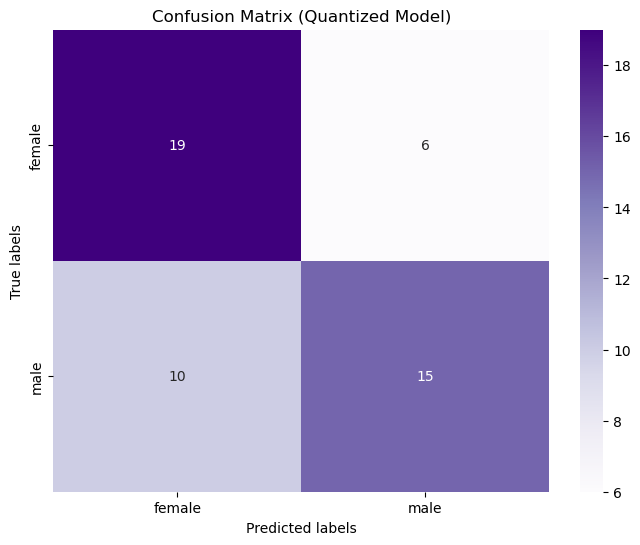

In [31]:
# Plot confusion matrix for quantized model
conf_matrix_quantized = confusion_matrix(test_labels_categ, model_quantized_predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_quantized, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Purples')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix (Quantized Model)')
plt.show()

**5. Conversion to C header file**

In [32]:
# Function: Convert a TensorFlow Lite model into a C source file
def hex_to_c_array(hex_data, var_name):

  c_str = ''

  # Create header guard
  c_str += '#ifndef ' + var_name.upper() + '_H\n'
  c_str += '#define ' + var_name.upper() + '_H\n\n'

  # Add array length at top of file
  c_str += '\nunsigned int ' + var_name + '_len = ' + str(len(hex_data)) + ';\n'

  # Declare C variable
  c_str += 'unsigned char ' + var_name + '[] = {'
  hex_array = []
  for i, val in enumerate(hex_data) :

    # Construct string from hex
    hex_str = format(val, '#04x')

    # Add formatting so each line stays within 80 characters
    if (i + 1) < len(hex_data):
      hex_str += ','
    if (i + 1) % 12 == 0:
      hex_str += '\n '
    hex_array.append(hex_str)

  # Add closing brace
  c_str += '\n ' + format(' '.join(hex_array)) + '\n};\n\n'

  # Close out header guard
  c_str += '#endif //' + var_name.upper() + '_H'

  return c_str

In [33]:
# Write TFLite model to a C source (or header) file
with open("audio_gender_classification_model.h", 'w') as file:
    file.write(hex_to_c_array(tflite_model, "audio_gender_classification_model"))